# Assignment 3 — Authorship Attribution

Predict the author (20 classes) of each fanfiction snippet.

In [1]:
from src.dataloader import load_all

splits = load_all()
for name, (texts, authors) in splits.items():
    print(f"{name}: {len(texts)} snippets, {len(set(authors))} authors")

train: 2138 snippets, 20 authors
dev: 268 snippets, 20 authors
test: 267 snippets, 20 authors


In [2]:
from src.features import extract_features
from src.model import classify

train_texts, train_y = splits["train"]
dev_texts, dev_y = splits["dev"]

train_X = [extract_features(t) for t in train_texts]
dev_X = [extract_features(t) for t in dev_texts]

pred = classify(train_X, train_y, dev_X)

F1 (micro): 0.478
Macro-F1  : 0.37


<Axes: xlabel='Predicted author', ylabel='True author'>

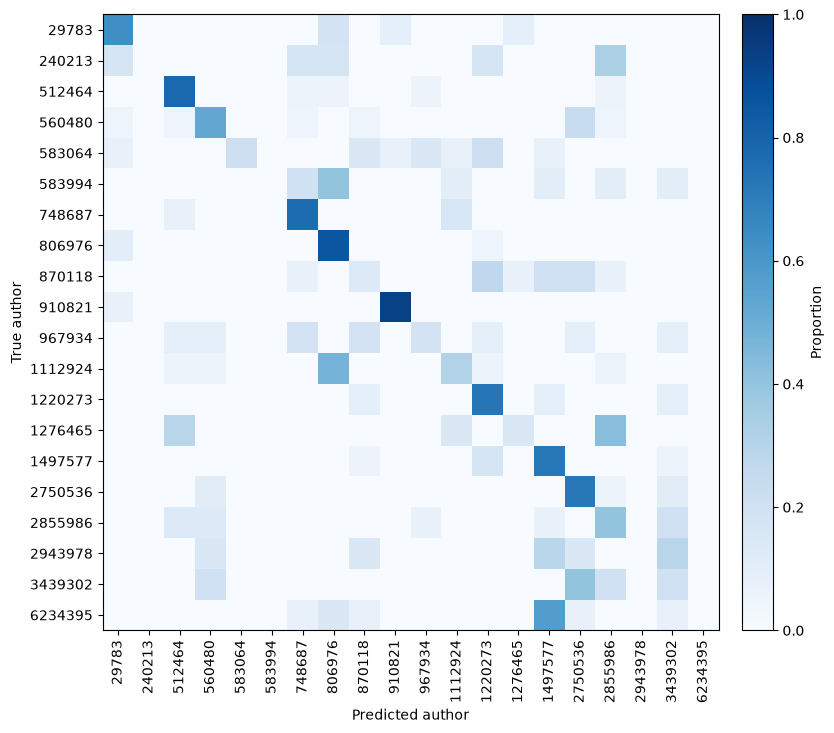

In [3]:
from src.evaluation import f1, macro_f1, confusion

print("F1 (micro):", round(f1(dev_y, pred), 3))
print("Macro-F1  :", round(macro_f1(dev_y, pred), 3))
confusion(dev_y, pred)

## Ablation analysis

Leave one feature group out at a time and check how the score drops. A lower score means the group was more informative.

11 features in 4 groups
group left out    micro-F1  macro-F1
all (baseline)       0.478     0.370
lexical              0.396     0.296
syntactic            0.358     0.251
punctuation          0.220     0.161
character            0.470     0.364


<Axes: xlabel='Feature group left out', ylabel='Macro-F1'>

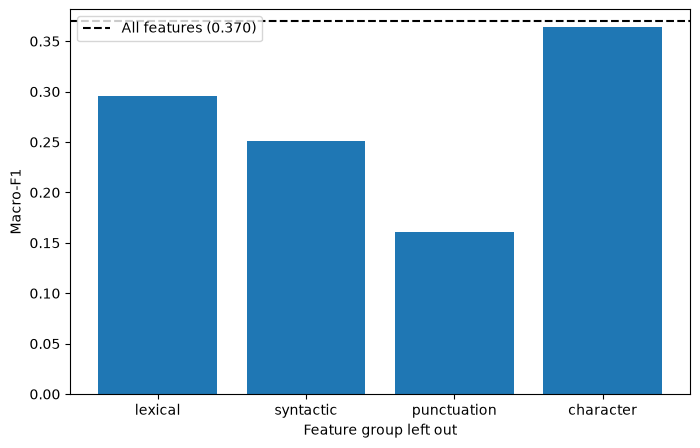

In [4]:
from src.features import FEATURE_NAMES, FEATURE_GROUPS
from src.ablation import ablate, plot_ablation

print(f"{len(FEATURE_NAMES)} features in {len(FEATURE_GROUPS)} groups")

scores = ablate(FEATURE_GROUPS, train_X, train_y, dev_X, dev_y)

print(f"{'group left out':<16}{'micro-F1':>10}{'macro-F1':>10}")
for name, m in scores.items():
    label = "all (baseline)" if name == "all" else name
    print(f"{label:<16}{m['micro_f1']:>10.3f}{m['macro_f1']:>10.3f}")

plot_ablation(scores)